### Thorium oligomerisation project - Potassium

### H-bond analysis

The following code runs a standardised MD analysis of hydrogen bonds, structural and solvent analyses. It will display plots in the notebook and save images to the directory your simulations are stored.

In [1]:
! pip list | grep MDAnalysis

MDAnalysis                2.9.0


In [6]:
import logging
import numpy as np
import MDAnalysis as mda
import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 500)
_fmt = "%(asctime)s - %(levelname)s: %(message)s"
logging.basicConfig(level=logging.INFO, format=_fmt)

### Water bridge analysis.

In [ ]:
simulation_path = '/media/corey/hzdrBackup/01_HZDR/_adhoc/04_Julia/03_ThNPAnions/01_Th_K/results/'

_, HETA, HETC = simulation_path.strip('/').split('/')[-2].split('_')

HETB = 'NO3'

In [8]:
topology = f'{simulation_path}/step5_1.psf' #MDA structure file
u = mda.Universe(topology)

/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/MDAnalysis/core/universe.py:150: UserWarning: No coordinate reader found for /media/corey/hzdrBackup/01_HZDR/_adhoc/04_Julia/03_ThNPAnions/01_Th_K/results//step5_1.psf. Skipping this file.
  warnings.warn('No coordinate reader found for {}. Skipping '
2025-09-04 10:23:08,255 - INFO: The attribute(s) types, masses have already been read from the topology file. The guesser will only guess empty values for this attribute, if any exists. To overwrite it by completely guessed values, you can pass the attribute to the force_guess parameter instead of the to_guess one
2025-09-04 10:23:08,257 - INFO: There is no empty types values. Guesser did not guess any new values for types attribute
2025-09-04 10:23:08,257 - INFO: There is no empty masses values. Guesser did not guess any new values for masses attribute


In [10]:
# Create combined traj - commented out for now

# from MDAnalysis.coordinates.XTC import XTCWriter

# u = mda.Universe(topology, f'{simulation_path}/step5_1.dcd')

# with mda.Writer(f'{simulation_path}/combined_trajectory.dcd', u.atoms.n_atoms) as writer:
#     # Write frames from the first trajectory
#     for ts in u.trajectory:
#         writer.write(u)  # Write each frame to the output file
    
#     # Loop through the remaining trajectory files and append frames
#     for i in range(1,201):
#         u.load_new(f'{simulation_path}/step5_{i}.dcd')  # Load next trajectory
#         for ts in u.trajectory:
#             writer.write(u)  # Write each frame to the output file

In [11]:
u = mda.Universe(topology, f'{simulation_path}/combined_trajectory.dcd')

/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
2025-09-04 10:23:29,052 - INFO: The attribute(s) types, masses have already been read from the topology file. The guesser will only guess empty values for this attribute, if any exists. To overwrite it by completely guessed values, you can pass the attribute to the force_guess parameter instead of the to_guess one
2025-09-04 10:23:29,053 - INFO: There is no empty types values. Guesser did not guess any new values for types attribute
2025-09-04 10:23:29,054 - INFO: There is no empty masses values. Guesser 

In [12]:
print(u.segments.segids)

['CLA' 'HETA' 'HETB' 'HETC' 'SOD' 'SOLV']


In [13]:
print("Water atom names:", np.unique(u.select_atoms("segid SOLV").names))
print(f"{HETB} atom names:", np.unique(u.select_atoms("segid HETB").names))

Water atom names: ['H1' 'H2' 'OH2']
NO3 atom names: ['N1' 'O1' 'O2' 'O3']


In [14]:
print("Donors:", u.select_atoms("segid SOLV and name OH2"))
print("Hydrogens:", u.select_atoms("segid SOLV and name H1 H2"))
print("Acceptors:", u.select_atoms("(segid HETB and name O1 O2 O3) or (segid SOLV and name OH2)"))


Donors: <AtomGroup [<Atom 45: OH2 of type 3 of resname TIP3, resid 1 and segid SOLV>, <Atom 48: OH2 of type 3 of resname TIP3, resid 2 and segid SOLV>, <Atom 51: OH2 of type 3 of resname TIP3, resid 3 and segid SOLV>, ..., <Atom 3858: OH2 of type 3 of resname TIP3, resid 1272 and segid SOLV>, <Atom 3861: OH2 of type 3 of resname TIP3, resid 1273 and segid SOLV>, <Atom 3864: OH2 of type 3 of resname TIP3, resid 1274 and segid SOLV>]>
Hydrogens: <AtomGroup [<Atom 46: H1 of type 1 of resname TIP3, resid 1 and segid SOLV>, <Atom 47: H2 of type 1 of resname TIP3, resid 1 and segid SOLV>, <Atom 49: H1 of type 1 of resname TIP3, resid 2 and segid SOLV>, ..., <Atom 3863: H2 of type 1 of resname TIP3, resid 1273 and segid SOLV>, <Atom 3865: H1 of type 1 of resname TIP3, resid 1274 and segid SOLV>, <Atom 3866: H2 of type 1 of resname TIP3, resid 1274 and segid SOLV>]>
Acceptors: <AtomGroup [<Atom 4: O1 of type 364 of resname NO31, resid 3 and segid HETB>, <Atom 5: O2 of type 364 of resname NO31,

In [15]:
print(u)
print("Number of atoms:", len(u.atoms))
print("Number of residues:", len(u.residues))
print("Number of segments:", len(u.segments))
print("Number of frames in trajectory:", len(u.trajectory))

<Universe with 3874 atoms>
Number of atoms: 3874
Number of residues: 1296
Number of segments: 6
Number of frames in trajectory: 19902


In [19]:
print(f"Atoms in {HETA} segment:", np.unique(u.select_atoms("segid HETA").names))
print(f"Atoms in {HETB} segment:", np.unique(u.select_atoms("segid HETB").names))

Atoms in Th segment: ['TH3P']
Atoms in NO3 segment: ['N1' 'O1' 'O2' 'O3']


In [ ]:
stride = 100 # keep every 100th frame

In [ ]:
from analyses.interaction_analysis import HydrogenBondCoordinationAnalyser

analyser = HydrogenBondCoordinationAnalyser(universe=u, stride=stride)
analyser.run_all()

# Sanity check
print("H-bond counts HETA-HETB:", analyser.segment_pair_hbond_counts("HETA", "HETB"))
print("Graphs at frame 0:", analyser.graphs[0])
print("Water-water H-bonds near HETA:", analyser.water_water_near_heta)

2025-09-04 10:24:04,398 - INFO: Choosing frames to analyze
2025-09-04 10:24:04,399 - INFO: Starting preparation
2025-09-04 10:24:12,839 - INFO: Finishing up
/home/corey/miniconda3/envs/docking_md/lib/python3.11/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:809: DeprecationWarning: The `hbonds` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.hbonds` instead.
  warnings.warn(wmsg, DeprecationWarning)


H-bond counts HETA-HETB: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Graphs at frame 0: Graph with 2671 nodes and 3781 edges
Water-water H-bonds near HETA: [34 33 41 44 51 47 48 41 48 54 53 40 44 45 51 53 54 57 63 56 60 62 56 54
 57 57 51 47 49 54 54 57 62 43 59 60 52 62 58 46 47 49 49 53 58 47 46 39
 57 63 57 56 61 64 54 60 49 61 56 48 56 47 52 49 59 55 51 49 41 56 46 48
 52 45 42 37 33 38 33 38 36 56 41 40 42 50 43 45 54 40 38 39 39 34 38 32
 38 36 32 37 40 44 44 44 48 52 49 46 40 40 48 45 48 45 52 44 54 50 51 43
 46 51 52 38 43 44 47 39 39 50 44 47 45 55 51 38 47 45 52 53 58 60 40 39
 47 46 44 39 42 50 43 53 43 37 40 39 41 44 

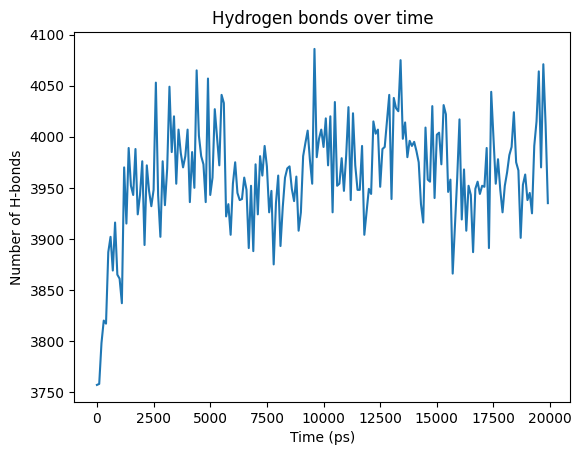

In [ ]:
# Sanity check - plot all H-bonds in the system

import matplotlib.pyplot as plt

hbonds_per_frame = analyser.ghb.count_by_time()
times = analyser.ghb.times  # time (ps) corresponding to each frame

plt.plot(times, hbonds_per_frame)
plt.xlabel('Time (ps)')
plt.ylabel('Number of H-bonds')
plt.title('Hydrogen bonds over time')
plt.show()

In [ ]:
from analyses.interaction_analysis import InteractionAnalysis

analysis = InteractionAnalysis(analyser)
analysis.run()

# Now access results:
print(analysis.times)
print(analysis.counts_hetb_solv)
print(analysis.coord_counts_hetb)
print(analysis.water_mediated_heta)

[0.0, 100.00000328495406, 200.00000656990812, 300.0000098548622, 400.00001313981625, 500.0000164247703, 600.0000197097244, 700.0000229946785, 800.0000262796325, 900.0000295645866, 1000.0000328495406, 1100.0000361344946, 1200.0000394194487, 1300.0000427044029, 1400.000045989357, 1500.0000492743109, 1600.000052559265, 1700.000055844219, 1800.0000591291732, 1900.0000624141271, 2000.0000656990812, 2100.0000689840354, 2200.0000722689892, 2300.0000755539436, 2400.0000788388975, 2500.000082123852, 2600.0000854088057, 2700.0000886937596, 2800.000091978714, 2900.000095263668, 3000.0000985486217, 3100.000101833576, 3200.00010511853, 3300.0001084034843, 3400.000111688438, 3500.000114973392, 3600.0001182583464, 3700.0001215433003, 3800.0001248282542, 3900.0001281132086, 4000.0001313981625, 4100.000134683117, 4200.000137968071, 4300.000141253025, 4400.0001445379785, 4500.000147822933, 4600.000151107887, 4700.000154392841, 4800.000157677795, 4900.000160962749, 5000.000164247704, 5100.0001675326575, 

Plots of non-normalised data.

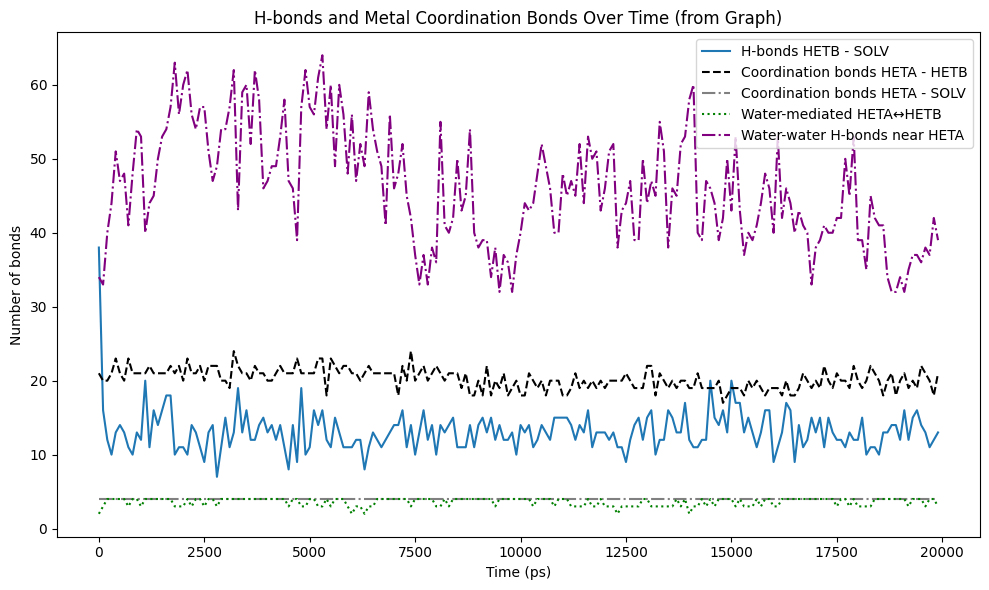

In [24]:
# Plotting
plt.figure(figsize=(10,6))

plt.plot(times, analysis.counts_hetb_solv, label="H-bonds HETB - SOLV")

plt.plot(times, analysis.coord_counts_hetb, label="Coordination bonds HETA - HETB", linestyle='--', color='black')
plt.plot(times, analysis.coord_counts_solv, label="Coordination bonds HETA - SOLV", linestyle='-.', color='gray')

plt.plot(times, analysis.water_mediated_heta, label="Water-mediated HETA↔HETB", linestyle=':', color='green')
plt.plot(analyzer.ghb.times, analysis.water_water_near_heta_graph, label="Water-water H-bonds near HETA", linestyle='-.', color='purple')

plt.xlabel("Time (ps)")
plt.ylabel("Number of bonds")
plt.title("H-bonds and Metal Coordination Bonds Over Time (from Graph)")
plt.legend()
plt.tight_layout()
plt.show()


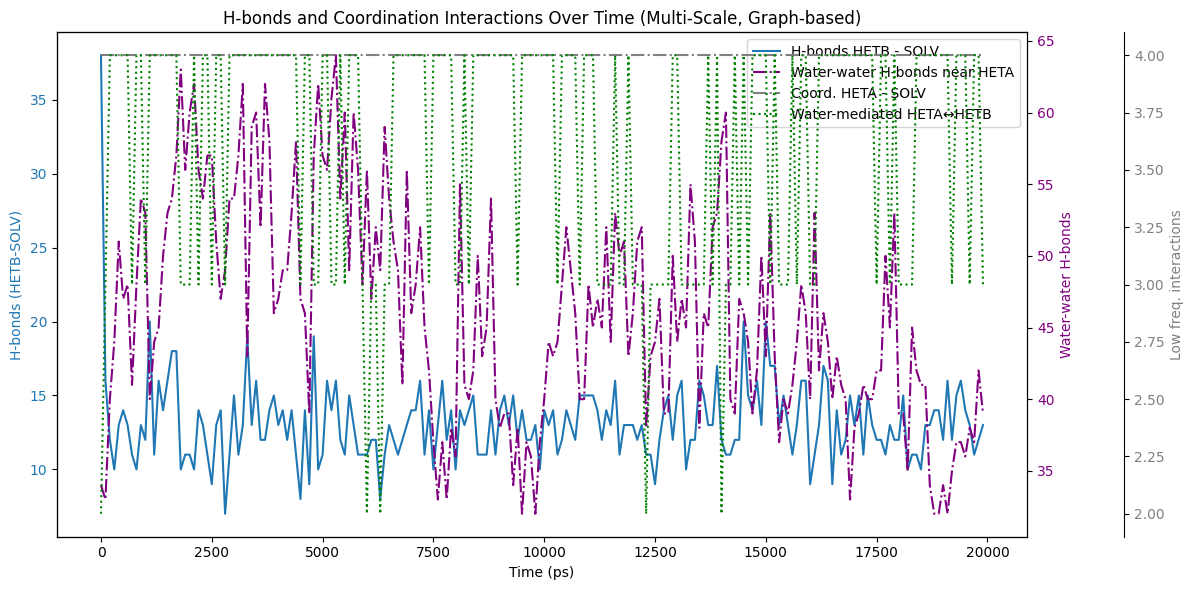

In [25]:
# --- Plotting with 3 y-axes ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Axis 1: Medium-scale H-bonds HETB-SOLV
ax1.set_xlabel("Time (ps)")
ax1.set_ylabel("H-bonds (HETB-SOLV)", color="tab:blue")
ax1.plot(times, analysis.counts_hetb_solv, label="H-bonds HETB - SOLV", color="tab:blue")
ax1.tick_params(axis='y', labelcolor="tab:blue")

# Axis 2: Water-water H-bonds (high-scale)
ax2 = ax1.twinx()
ax2.set_ylabel("Water-water H-bonds", color="purple")
ax2.plot(times, analysis.water_water_near_heta_graph, label="Water-water H-bonds near HETA", color="purple", linestyle="-.")
ax2.tick_params(axis='y', labelcolor="purple")

# Axis 3: Low-frequency interactions (Coord. HETA - SOLV + Water-mediated)
ax3 = ax1.twinx()
ax3.spines["right"].set_position(("axes", 1.1))  # Offset 3rd axis
ax3.set_ylabel("Low freq. interactions", color="gray")

ax3.plot(times, analysis.coord_counts_solv, label="Coord. HETA - SOLV", linestyle='-.', color="gray")
ax3.plot(times, analysis.water_mediated_heta, label="Water-mediated HETA↔HETB", linestyle=':', color="green")
ax3.tick_params(axis='y', labelcolor="gray")

ax3.spines["right"].set_visible(True)

# Combine legends from all axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()

lines = lines1 + lines2 + lines3
labels = labels1 + labels2 + labels3

ax1.legend(lines, labels, loc="upper right")

plt.title("H-bonds and Coordination Interactions Over Time (Multi-Scale, Graph-based)")
plt.tight_layout()
plt.show()

Plot of normalised data.

In [26]:
def normalize(arr):
    arr = np.array(arr, dtype=float)
    min_val = np.min(arr)
    max_val = np.max(arr)
    if max_val - min_val == 0:
        return np.zeros_like(arr)  # or arr - min_val to get zeros
    else:
        return (arr - min_val) / (max_val - min_val)

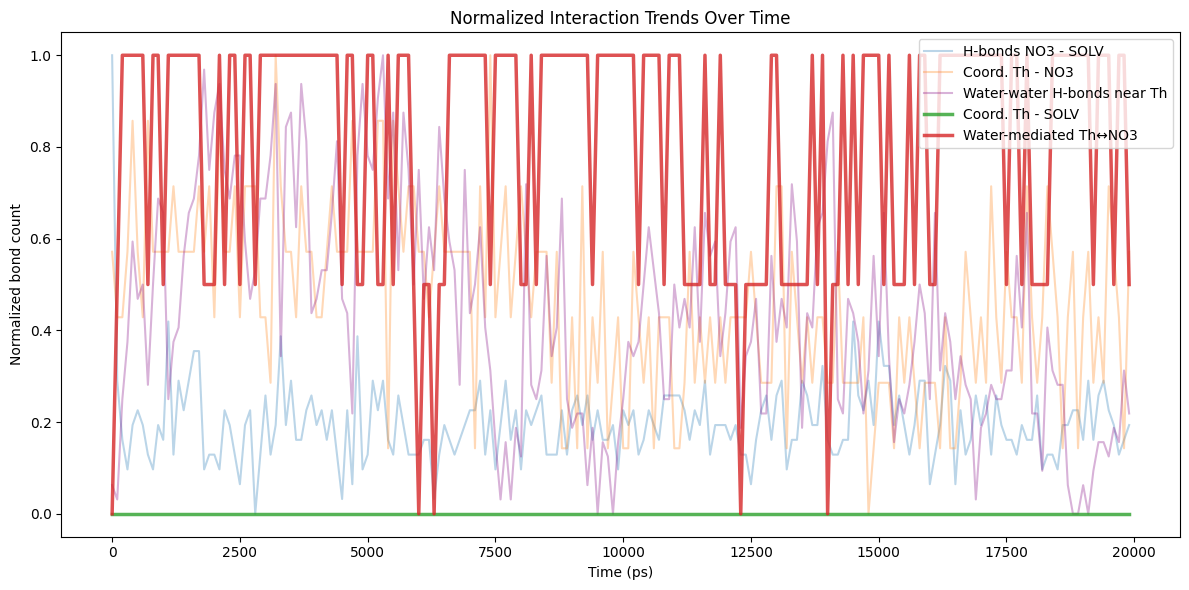

In [27]:
# --- Plotting normalized data ---
plt.figure(figsize=(12, 6))

plt.plot(times, normalize(analysis.counts_hetb_solv), label=f"H-bonds {HETB} - SOLV", alpha=0.3)
plt.plot(times, normalize(analysis.coord_counts_hetb), label=f"Coord. {HETA} - {HETB}", alpha=0.3)
plt.plot(times, normalize(analysis.water_water_near_heta_graph), label=f"Water-water H-bonds near {HETA}", color="purple", alpha=0.3)
plt.plot(times, normalize(analysis.coord_counts_solv), label=f"Coord. {HETA} - SOLV", linewidth=2.5, alpha=0.8)
plt.plot(times, normalize(analysis.water_mediated_heta), label=f"Water-mediated {HETA}↔{HETB}", linewidth=2.5, alpha=0.8)

plt.xlabel("Time (ps)")
plt.ylabel("Normalized bond count")
plt.title("Normalized Interaction Trends Over Time")
plt.legend()
plt.tight_layout()
plt.show()
